<a href="https://colab.research.google.com/github/SajaFawagreh/SYSC4415/blob/main/W2026/Assignments/A2/A2_SYSC4415_W26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SYSC4415 W26 Assignment 2 – Fire Hydrant Detection 🚒

Special thanks to Nader Ibrahim for assembling the dataset. For more details, please refer to the paper:

Ibrahim N, Dick K, Green JR. Computer Vision Fire Hydrant Obstruction Detection System. In2024 IEEE Canadian Conference on Electrical and Computer Engineering (CCECE) 2024 Aug 6 (pp. 799-805). IEEE.


Questions? Please use the Brightspace Discussion Board.

Deadline: See Brightspace end date.

## Instructions
DO NOT wait until the last minute to complete this assignment as training the models might take longer. Also leverage the free GPU provided by colab to make your training faster.


Follow all steps carefully. Your solutions must be self-contained in this notebook. No other supplementary materials or files will be accepted. As soon as I open your notebook, I will click "Runtime" → "Run all". Ensure your notebook runs without errors and displays results clearly.


You are asked to provide both code and text to address discussion questions. For the text answers, see the markdown cells with the ❓ emoji for questions and enter your answers following the ✅ emoji.

Provide sufficient comments in your code to describe its functionality. Do not remove any necessary libraries as this will cause errors.

Download the dataset from Brightspace and store it in your Google Drive under "My Drive" (not in any subfolder). Check the file location via right-click → File Information → Details → Location.

Submit your notebook as a `.ipynb` file named: `SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb` on Brightspace. No other submission methods will be accepted.


## Dataset
Provided on Brightspace.

#### Dataset details:
- Training Images: 2,272  
- Validation Images: 563  
- Labels: 0 = No Fire Hydrant, 1 = Fire Hydrant  
- Imbalanced dataset (most images do not contain a hydrant).

#### Dataset Information
The dataset contains two main folders:
- `train/`: Contains the training images and a CSV file with labels.
- `valid/`: Contains the validation images and a CSV file with labels.

Each folder includes:
- Images of fire hydrants and non-fire hydrants.
- A CSV file (`_classes.csv`) mapping each image filename to its label:
  - `0` for no fire hydrant.
  - `1` for fire hydrant.

Ensure the zip file of the dataset (FH_detection_data.zip) to your Google Drive and placed under "My Drive" without any subfolders to keep the paths consistent.



## Steps

### 1) Initial Setup
Import necessary libraries


In [2]:
# Import all the necessary libraries here

import pandas as pd
import os

Mount Google Drive and unzip the dataset.

In [3]:
## Code provided by TA. DO NOT CHANGE THIS CELL

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip the dataset
!unzip /content/drive/MyDrive/FH_detection_data.zip -d /content/


# Dataset path
train_data_path = "/content/train"
valid_data_path = "/content/valid"
train_label = pd.read_csv('/content/train/_classes.csv')
valid_label = pd.read_csv('/content/valid/_classes.csv')

Mounted at /content/drive
Archive:  /content/drive/MyDrive/FH_detection_data.zip
   creating: /content/train/
 extracting: /content/train/10063782964_891eedde4e_z_jpg.rf.4caba9d0e35546b469aa896df780d833.jpg  
 extracting: /content/train/100_PNG.rf.d52fbff94c483761d0644a1e8abe4c95.jpg  
 extracting: /content/train/101_PNG.rf.f1335e18f815c8c8044a94c09db7f025.jpg  
 extracting: /content/train/102378468_d8132a415b_z_jpg.rf.6bc008d0d532d3365f580b7aaa7623e3.jpg  
 extracting: /content/train/102_PNG.rf.160c945e0881c92a078a14069d9a6b9a.jpg  
 extracting: /content/train/102_jpg.rf.17df75e9dda0f851c9f5e1d554f07488.jpg  
 extracting: /content/train/103357395_388d701e12_z_jpg.rf.a54c985e93402af49ba422f005e702d8.jpg  
 extracting: /content/train/103_jpg.rf.a649213f3998906bf2298607f82ee839.jpg  
 extracting: /content/train/104351403_25e959f878_z_jpg.rf.43156bd0a74313df69967d88e5e6a268.jpg  
 extracting: /content/train/104_PNG.rf.c14671a6a52ae05f9ae2bf1df7e4316e.jpg  
 extracting: /content/train/104_

----

### 2) Data Exploration
1. Load dataset into a pandas DataFrame.
2. Display display three sample images from each class
3. Create separately class distribution plots of the train and validation data
[Requires 6 sample images (three from each class) and two plots of class distribution (train and validation)]

❓ Why is it important to check for class imbalance before training? How might this affect our model?  
✅ Your answer here
..



Sample images from class 0: 



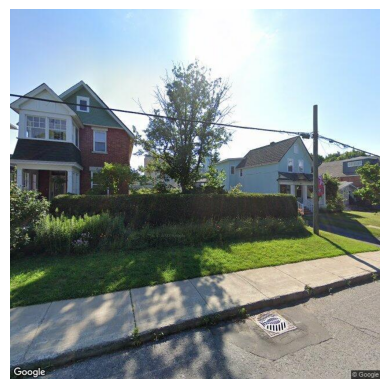

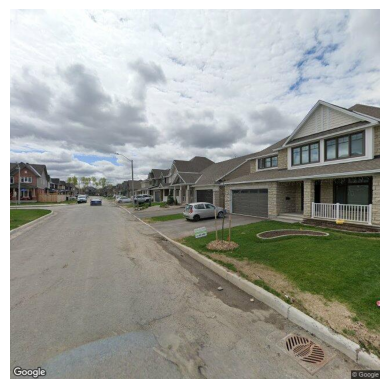

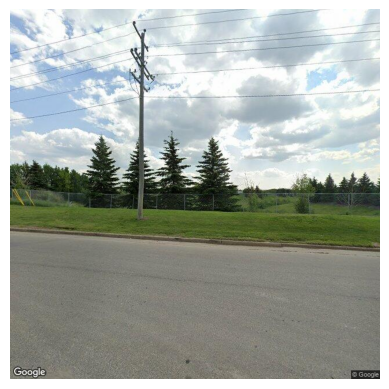


Sample images from class 1: 



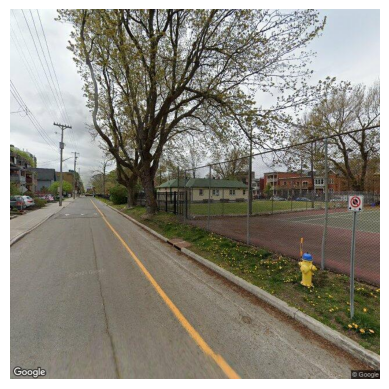

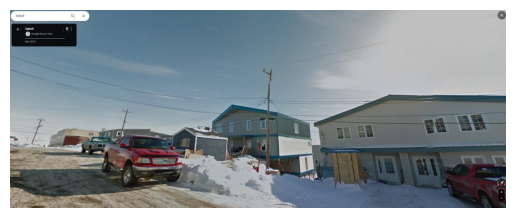

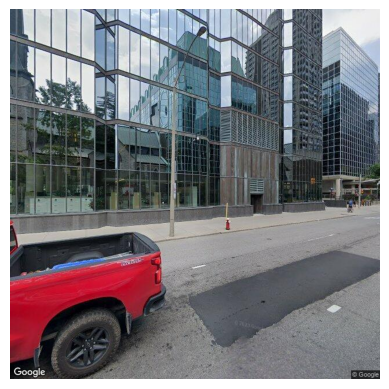


Class distribution plot of the train data: 



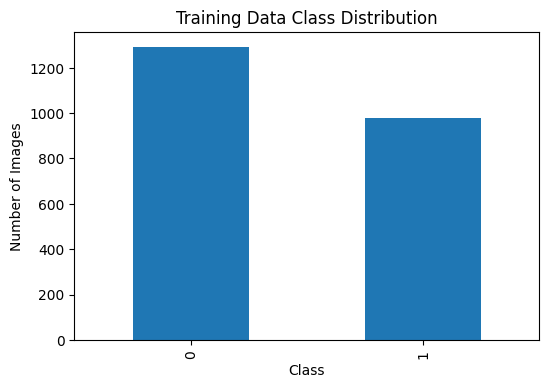


Class distribution plot of the validation data: 



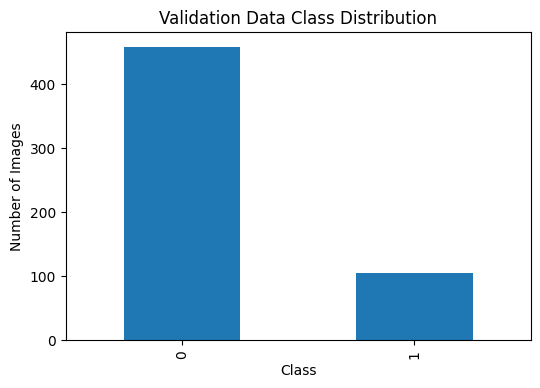

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# Load dataset into pandas DataFrame
train_df = pd.DataFrame(train_label, columns=["filename", "Fire Hydrants"])
valid_df = pd.DataFrame(valid_label, columns=["filename", "Fire Hydrants"])

# Display three sample images from each class
class0_samples = train_df[train_df["Fire Hydrants"] == 0].sample(3)
class1_samples = train_df[train_df["Fire Hydrants"] == 1].sample(3)

def display_images(class_samples):
  for i, row in class_samples.iterrows():
    file_name = row['filename']
    file_path = os.path.join(train_data_path, file_name)
    image = Image.open(file_path)
    plt.axis('off')
    plt.imshow(image)
    plt.show()

print("\nSample images from class 0: \n")
display_images(class0_samples)

print("\nSample images from class 1: \n")
display_images(class1_samples)

# Create separately class distribution plots of the train and validation data
print("\nClass distribution plot of the train data: \n")

# Training data
plt.figure(figsize=(6,4))
train_df["Fire Hydrants"].value_counts().plot(kind='bar')
plt.title("Training Data Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

print("\nClass distribution plot of the validation data: \n")

# Validation data
plt.figure(figsize=(6,4))
valid_df["Fire Hydrants"].value_counts().plot(kind='bar')
plt.title("Validation Data Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


---

### 3) Preprocessing
- Resize images to 128x128.
- Apply any other necessary transformations that you feel can help.

❓ Would one-hot encoding be necessary for binary classification? Why or why not?  
✅ Your answer here..

In [5]:
from torchvision import transforms

# Training transformations (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),                     # Resize images to 128x128
    transforms.Lambda(lambda img: img.convert("RGB")), # convert to RGB
    transforms.RandomHorizontalFlip(),                 # augmentation
    transforms.RandomRotation(10),                     # augmentation
    transforms.ToTensor(),                             # convert to tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )                                                  # normalization
])

# Validation transformations (no augmentation)
valid_transforms = transforms.Compose([
    transforms.Resize((128, 128)),                     # Resize images to 128x128
    transforms.Lambda(lambda img: img.convert("RGB")), # convert to RGB
    transforms.ToTensor(),                             # convert to tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )                                                  # normalization
])

---

### 4) Creating the Baseline Model
Create a CNN with:
- Two convolutional layers to extract features from the images.
- Max pooling layers after each convolution to reduce spatial dimensions.
- Fully connected layers to perform classification.
- A sigmoid activation function at the output layer to output a probability between 0 and 1.

Required architecture:
- Input: RGB images resized to 128x128 pixels.
- Conv2d (3 input channels, 32 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the first Conv2d.
- Conv2d (32 input channels, 64 output channels, kernel size 3, padding 1)
- MaxPool2d (kernel size 2, stride 2, padding 0) – applied after the second Conv2d.
- Flatten
- Linear layer with 128 units
- Output Linear layer with 1 unit and sigmoid activation



This model will be trained to classify whether an image contains a fire hydrant or not.


❓ List three ways to improve the baseline model (e.g., adding dropout to... , using batch normalization to..., or increasing the number of layers to...,
be sure to come up with your own ideas!). Provide a brief explanation for each.

✅

1. Adding dropout can help prevent overfitting by randomly turning off some neurons during training, which makes the network rely less on specific features and generalize better.

2. Using batch normalization can make training more stable and sometimes faster, since it keeps the outputs of layers more normalized and helps the optimizer converge more smoothly.

3. Adding more convolutional layers can improve feature extraction by letting the model learn more detailed patterns in the images, which may lead to better classification performance.

In [6]:
import torch
import torch.nn as nn

class FireHydrantCNN(nn.Module):
    def __init__(self):
        super(FireHydrantCNN, self).__init__()

        # First CONV => RELU => POOL layer
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        # Second CONV => RELU => POOL layer
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        # FC => OUTPUT layer
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

model = FireHydrantCNN()
print(model)

FireHydrantCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


---

### 5) Training and Evaluation
Train your CNN using Binary Cross Entropy Loss and an Adam optimizer. Use a learning rate of 0.001. Iterate over your dataset for 10 epochs and track the loss. Train using the train data in /train.

Evaluate your model on the test data in /valid using Precision, Recall, and F1-Score to assess performance.


❓ Which evaluation metric you think is the most suitable in our case, and why?

✅ Your answer here


Display the confusion matrix.

❓ Explain the confusion matrix to a non-technical audience and relate it to your chosen metric.  
✅ Your answer here


===== Baseline =====


Training model using Binary Cross Entropy Loss and an Adam optimizer:

Epoch 1/10, Loss: 0.6560
Epoch 2/10, Loss: 0.5127
Epoch 3/10, Loss: 0.4593
Epoch 4/10, Loss: 0.4128
Epoch 5/10, Loss: 0.3655
Epoch 6/10, Loss: 0.2938
Epoch 7/10, Loss: 0.2430
Epoch 8/10, Loss: 0.1707
Epoch 9/10, Loss: 0.1266
Epoch 10/10, Loss: 0.0528

Evaluating model on the test data:


Baseline Results:
Precision: 0.4110
Recall:    0.6442
F1-Score:  0.5019

Confusion Matrix:
[[363  96]
 [ 37  67]]


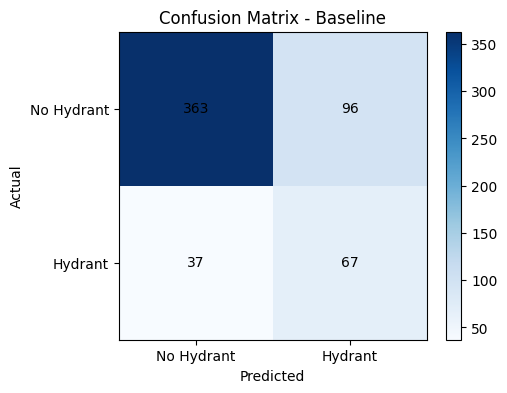

In [8]:
from torch import optim
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def load_and_process_data(df, data_path, transform, shuffle):
    images = []
    labels = []

    for _, row in df.iterrows():
        filename = row['filename']
        label = row['Fire Hydrants']

        image_path = os.path.join(data_path, filename)
        image = Image.open(image_path)
        image = transform(image)

        images.append(image)
        labels.append(label)

    image_tensor = torch.stack(images)
    labels_tensor = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

    dataset = TensorDataset(image_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=shuffle)

    return dataloader

def train_model(epochs, model, trainloader, loss_fn, optimizer):
    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0

        for X, y in trainloader:
            # Forward pass
            y_pred = model(X)

            # Compute loss
            loss = loss_fn(y_pred, y)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Add batch loss
            epoch_loss += loss.item()

        # Average loss for this epoch
        loss_avg = epoch_loss / len(trainloader)
        losses.append(loss_avg)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_avg:.4f}")

    return losses

def test_model(model, testloader, model_name):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in testloader:
            outputs = model(X)
            preds = (outputs >= 0.5).float()

            all_preds.extend(preds.squeeze().tolist())
            all_labels.extend(y.squeeze().tolist())

    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"{model_name} Results:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()
    plt.xticks([0,1], ["No Hydrant", "Hydrant"])
    plt.yticks([0,1], ["No Hydrant", "Hydrant"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.show()
    return precision, recall, f1

def run_experiment(model_class, model_name):
    print(f"\n===== {model_name} =====\n")

    # Create model
    model = model_class()

    # BCE Loss and Adam optimizer
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train
    print("Training model using Binary Cross Entropy Loss and an Adam optimizer:\n")
    num_epochs = 10
    train_model(num_epochs, model, train_dataloader, loss_fn, optimizer)

    # Evaluate
    print("\nEvaluating model on the test data:\n")
    precision, recall, f1 = test_model(model, valid_dataloader, model_name)

    return precision, recall, f1

# Load training data
train_dataloader = load_and_process_data(
    train_df,
    train_data_path,
    train_transforms,
    shuffle=True
)

# Load validation data
valid_dataloader = load_and_process_data(
        valid_df,
        valid_data_path,
        valid_transforms,
        shuffle=False
)

# Train Baseline model
results = {}
results["Baseline"] = run_experiment(FireHydrantCNN, "Baseline")


---


### 6) Model Improvements
Apply and evaluate three improvements ideas that you mentioned in the Baseline CNN question (Step 4).
Implement each idea separately, train a model with that improvement, and report the performance of each model using the metrics from Step 5. As above, train using the data in /train and test using the data in /valid.


❓ Which model would you deploy? Why?  
✅ Your answer here


===== Dropout Model =====


Training model using Binary Cross Entropy Loss and an Adam optimizer:

Epoch 1/10, Loss: 0.6177
Epoch 2/10, Loss: 0.5398
Epoch 3/10, Loss: 0.5042
Epoch 4/10, Loss: 0.4671
Epoch 5/10, Loss: 0.4472
Epoch 6/10, Loss: 0.4041
Epoch 7/10, Loss: 0.3593
Epoch 8/10, Loss: 0.3089
Epoch 9/10, Loss: 0.2407
Epoch 10/10, Loss: 0.2047

Evaluating model on the test data:


Dropout Model Results:
Precision: 0.3770
Recall:    0.6923
F1-Score:  0.4881

Confusion Matrix:
[[340 119]
 [ 32  72]]


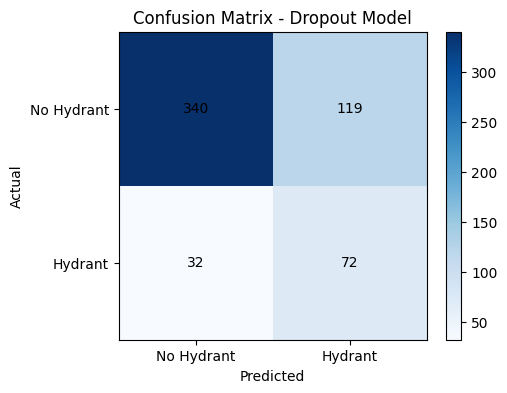


===== BatchNorm Model =====


Training model using Binary Cross Entropy Loss and an Adam optimizer:



In [ ]:
class FireHydrantCNN_Dropout(nn.Module):
    def __init__(self):
        super(FireHydrantCNN_Dropout, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

class FireHydrantCNN_BatchNorm(nn.Module):
    def __init__(self):
        super(FireHydrantCNN_BatchNorm, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

class FireHydrantCNN_ThreeConv(nn.Module):
    def __init__(self):
        super(FireHydrantCNN_ThreeConv, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

# Train Dropout model
results["Dropout"] = run_experiment(FireHydrantCNN_Dropout, "Dropout Model")

# Train BatchNorm model
results["BatchNorm"] = run_experiment(FireHydrantCNN_BatchNorm, "BatchNorm Model")

# Train ThreeConv model
results["ThreeConv"] = run_experiment(FireHydrantCNN_ThreeConv, "ThreeConv Model")

results_df = pd.DataFrame(results, index=["Precision", "Recall", "F1-Score"]).T
print(results_df)

---

### 7) Personal Inference Test
Test your trained model on at least FIVE new images (either collected using a camera or collected from the internet). Predict whether each image contains a fire hydrant and print the result.

Of your five images:
- Include at least one image of a fire hydrant that your model does not detect correctly.
- Include at least one image of a fire hydrant that your model does detect correctly.

❓ Challenge: Can you find an image that does not actually contain a fire hydrant, but your model believes that a hydrant is present?

✅ Your answer here

❓ Explain why you believe your model performed the way it did on each of your five images. What patterns or mistakes do you observe?

✅ Your answer here


In [ ]:
## Enter your code here..

---

### 8) (Optional) Transfer Learning with Pretrained CNN

#### Description:
In this optional step, fine-tune a pretrained CNN (e.g., ResNet50) on your dataset and compare its performance to your custom CNN.

- Use `torchvision.models.resnet50(pretrained=True)` as a starting model.

Reference: https://pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html
- Modify the final layer to fit your binary classification task (fire hydrant vs. no fire hydrant).
- Resize input images to **256x256** pixels.
- Fine-tune the model and evaluate its performance.
- Compare the results to your custom CNN in terms of accuracy, training time, and other relevant metrics.

#### Libraries to use:
```python
import torchvision.models as models
```

#### Student Code:
```python
# Your code here
```


------

### 9) Final Thoughts
❓ How would you improve the model in the future?

✅ Your answer here..


-----

## Final Question:
### ❓ Did you use an AI tool in completing your assignment? If yes, which AI tool(s) did you use? How did you prompt it? How you validate the response?

✅ Your answer here..


---

## Submission
Submit your `.ipynb` notebook on Brightspace using the following name format:  
`SYSC4415W25_A2_FIRSTNAME_LASTNAME_StudentID.ipynb`

